# Lattice-encrypted OFDM under realistic wireless channels — multipath / Rayleigh fading

**Problem statement.** Lattice-based encryption can obscure QAM/OFDM constellations while allowing
recovery of the transmitted data after decryption (Abdallah 2024). The published evaluation is
limited to an AWGN channel; realistic wireless links suffer **multipath propagation** and
**Rayleigh fading** (3GPP channel conditions). This notebook introduces a multipath Rayleigh
fading channel and measures its effect on constellation recovery, BER, symbol error rate (SER),
and the robustness of the encryption scheme itself.

**Channel model.** An L-tap tapped-delay-line (TDL) with i.i.d. Rayleigh taps
h_l ~ CN(0, p_l) and an exponential power-delay profile (normalised so Σp_l = 1),
quasi-static per OFDM frame (block fading). Because the number of taps satisfies
L − 1 ≤ CP length, the cyclic prefix converts the multipath convolution into a
per-subcarrier multiplication — the defining property of CP-OFDM:

&nbsp;&nbsp;&nbsp;&nbsp; Y_k = H_k · X_k + W_k,&nbsp;&nbsp; H = FFT_N(h)

so the channel is applied exactly in the frequency domain (double precision, which the
lattice arithmetic requires). The receiver equalises with perfect CSI, either
**zero-forcing** (X̂ = Y/H, noise enhancement 1/|H_k|² on faded subcarriers) or **MMSE**.

**Why encryption changes the fading story.** In clear OFDM a deep fade corrupts only the
symbols on the faded subcarriers. After lattice encryption, decryption multiplies the whole
received vector by R⁻¹ (Babai) — so the enhanced noise from even a single deeply-faded
subcarrier is **spread across all N coordinates of the block**. One bad subcarrier can take
down the entire decrypted vector. The Monte-Carlo section quantifies this avalanche effect.

*(No new dependencies are required: the channel is implemented in `torch` complex128. For
standardised 3GPP TDL-A/B/C profiles with Doppler, `sionna.phy.channel.tr38901` can be
substituted later.)*

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
import math
import contextlib, io
import numpy as np
import torch
import matplotlib.pyplot as plt
import sionna
import sionna.phy

%matplotlib inline

from lattice import LatticeBasedEncryptor, qam16_lattice_to_normalized, qam16_slicer_lattice
from metrics import hadamard_ratio, hadamard_quality, matrix_condition_number, random_unimodular_matrix, generate_lattice_bases
from ber import bit_error_rate, nearest_neighbor_qam_demapper, db_to_linear_amplitude, receiver_amplifier, snr_sweep_ber, plot_ber_vs_snr
from plots import plot_constellation, plot_rx_only

## Shared setup
Parameters, ciphertext-power-calibrated key generation (the waterfall position is set by the
ciphertext power — see the AWGN notebook), the Rayleigh TDL channel, and both equalisers.

In [2]:
# --- PARAMETERS ---
num_bits_per_symbol  = 4        # 16-QAM
fft_size             = 512      # lattice dim = sub-carriers (> 350, Abdallah Sec. 4.3)
num_ofdm_symbols     = 14
cyclic_prefix_length = 8
n_taps               = 6        # multipath taps; n_taps-1 <= CP  ->  no ISI
pdp_decay            = 1.0      # exponential power-delay profile decay
channel_attenuation  = 0.5
FIXED_SIGMA          = 1.0
FIXED_K              = 48

binary_source = sionna.phy.mapping.BinarySource()
constellation = sionna.phy.mapping.Constellation("qam", num_bits_per_symbol)
mapper        = sionna.phy.mapping.Mapper(constellation=constellation)
qam_lattice_scale = torch.sqrt(torch.tensor(10.0, dtype=torch.float32))

# ── Ciphertext-power-calibrated keygen (same rationale as the AWGN notebook) ──
def make_calibrated_encryptor(n, target_rms, sigma=FIXED_SIGMA, k=FIXED_K,
                              band=(0.8, 1.35), draws_per_rung=3, verbose=True):
    ladder = [(1, 1), (2, 1), (1, 2), (1, 3), (2, 2)]      # increasing ciphertext power
    best, best_err, best_rms = None, float("inf"), 0.0
    for r, mc in ladder:
        for _ in range(draws_per_rung):
            with contextlib.redirect_stdout(io.StringIO()):
                e = LatticeBasedEncryptor(n=n, sigma=sigma, rounds=r, max_coeff=mc,
                                          badTh=0.9, max_bad_attempts=3, k=k, verbose=False)
            rms = math.sqrt(10.0 * (e.B.to(torch.complex128).abs() ** 2).sum().item() / n)
            ok  = e.info["sigma_min_secure"] < sigma < e.info["sigma_max_correct"]
            err = abs(math.log(rms / target_rms)) + (0.0 if ok else 10.0)
            if err < best_err:
                best, best_err, best_rms = e, err, rms
            if ok and band[0] < rms / target_rms < band[1]:
                if verbose:
                    print(f"  N={n}: rounds={r}, max_coeff={mc}, ciphertext RMS ≈ {rms:.0f}")
                return e
    if verbose:
        print(f"  N={n}: best effort, ciphertext RMS ≈ {best_rms:.0f}")
    return best

# ── Rayleigh multipath channel (frequency response, block fading per frame) ──
def rayleigh_freq_response(batch, n_fft, n_taps=n_taps, decay=pdp_decay):
    """L-tap TDL, Rayleigh taps, exponential PDP normalised to unit average power.
    Returns per-subcarrier response H with shape [batch, 1, n_fft] so one channel
    realisation applies to all OFDM symbols of a frame (quasi-static block fading)."""
    p = torch.exp(-decay * torch.arange(n_taps, dtype=torch.float64))
    p = p / p.sum()
    h = torch.sqrt(p / 2) * (torch.randn(batch, n_taps, dtype=torch.float64)
                             + 1j * torch.randn(batch, n_taps, dtype=torch.float64))
    H = torch.fft.fft(h.to(torch.complex128), n=n_fft, dim=-1)
    return H.unsqueeze(1)                                   # [batch, 1, n_fft]

def awgn128(shape, n0):
    return math.sqrt(n0 / 2.0) * (torch.randn(shape, dtype=torch.float64)
                                  + 1j * torch.randn(shape, dtype=torch.float64))

def equalize(Y, H_eff, N0, Px, method="zf"):
    """Perfect-CSI one-tap equalisation. H_eff includes the channel attenuation."""
    if method == "zf":
        return Y / H_eff
    if method == "mmse":
        G = H_eff.conj() / (H_eff.abs() ** 2 + N0 / Px)
        return G * Y
    raise ValueError(method)

def symbol_error_rate(decrypted_lattice, reference_lattice):
    return float((qam16_slicer_lattice(decrypted_lattice) != reference_lattice).float().mean())

print("Calibrating N=512 keypair (target ciphertext RMS 1550, matching the AWGN study):")
encryptor = make_calibrated_encryptor(fft_size, target_rms=1550)

Calibrating N=512 keypair (target ciphertext RMS 1550, matching the AWGN study):
  N=512: rounds=1, max_coeff=3, ciphertext RMS ≈ 1797


## End-to-end under fading: constellations, BER and SER
Same SNR for both channels so the comparison isolates the fading effect. The received
constellation is shown after **linear decryption B⁻¹** (Babai snaps to exact integers and
cannot show clouds); Babai + hard slicing is used for the BER/SER numbers.

--- ENCRYPTED SIGNAL CONSTELLATION ---


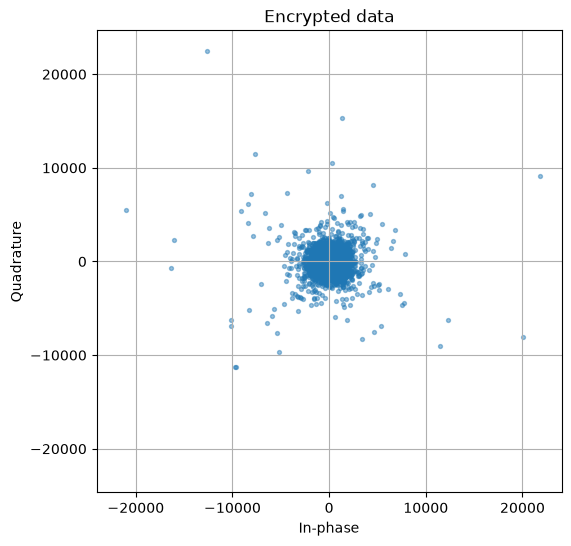

--- CHANNEL MAGNITUDE |H_k| (first frame): note the deep fades ---


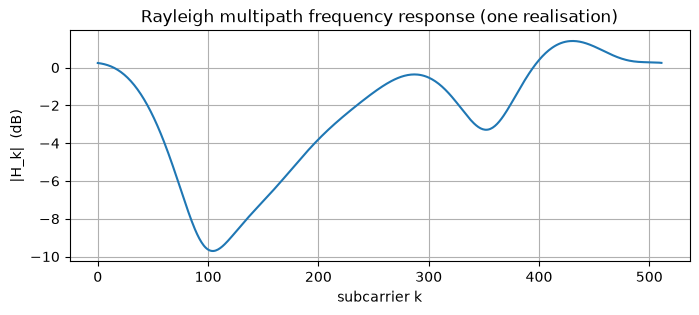

--- RESULTS at SNR = 46 dB (N = 512) ---


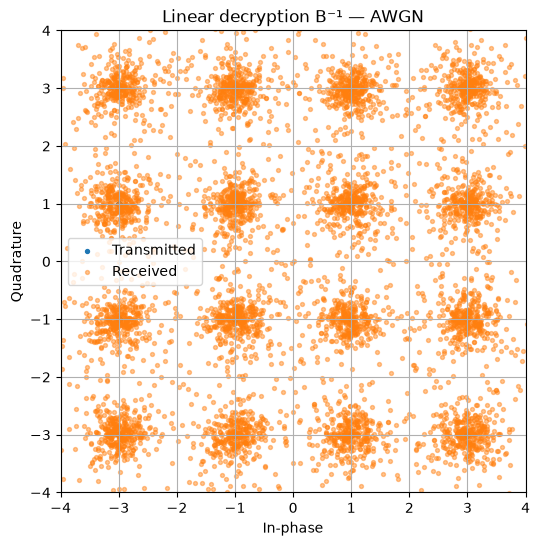

  AWGN            BER = 0.000e+00   SER = 0.000e+00


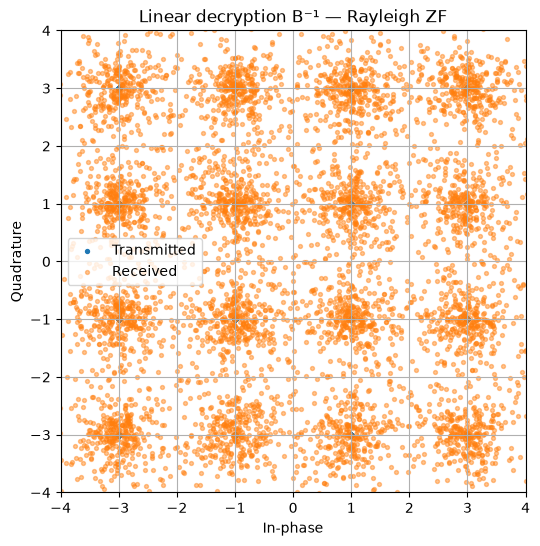

  Rayleigh ZF     BER = 2.131e-02   SER = 6.620e-02


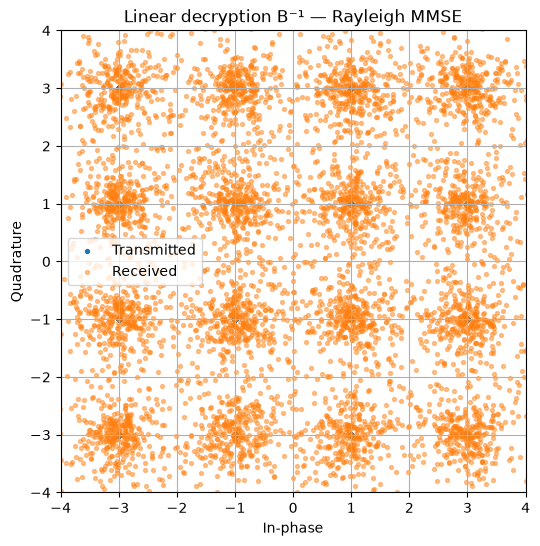

  Rayleigh MMSE   BER = 2.125e-02   SER = 6.602e-02


In [3]:
snr_demo_db = 46          # near the N=512 AWGN waterfall — fading damage is clearest here
batch_frames = 40

torch.manual_seed(0)
bits = binary_source([batch_frames, num_ofdm_symbols, fft_size, num_bits_per_symbol])
symbols = mapper(bits)
symbols_lattice = (symbols.squeeze(-1) * qam_lattice_scale).to(torch.complex128)

X  = encryptor.encrypt(symbols_lattice)                    # frequency-domain ciphertext
Px = (X.abs() ** 2).mean().item()
tx_power = channel_attenuation ** 2 * Px                   # E|H|^2 = 1 by construction
N0 = tx_power / (num_bits_per_symbol * 10 ** (snr_demo_db / 10))

print("--- ENCRYPTED SIGNAL CONSTELLATION ---")
plot_rx_only(X[0].to(torch.complex64), "Encrypted data")

# One channel draw, shared by every receiver below
H = rayleigh_freq_response(batch_frames, fft_size)
print("--- CHANNEL MAGNITUDE |H_k| (first frame): note the deep fades ---")
plt.figure(figsize=(8, 3))
plt.plot(20 * torch.log10(H[0, 0].abs()).numpy())
plt.xlabel("subcarrier k"); plt.ylabel("|H_k|  (dB)"); plt.grid(True)
plt.title("Rayleigh multipath frequency response (one realisation)")
plt.show()

receivers = {}
# AWGN reference
Y = channel_attenuation * X + awgn128(X.shape, N0)
receivers["AWGN"] = Y / channel_attenuation
# Rayleigh, ZF and MMSE
Y = channel_attenuation * H * X + awgn128(X.shape, N0)
receivers["Rayleigh ZF"]   = equalize(Y, channel_attenuation * H, N0, Px, "zf")
receivers["Rayleigh MMSE"] = equalize(Y, channel_attenuation * H, N0, Px, "mmse")

print(f"--- RESULTS at SNR = {snr_demo_db} dB (N = {fft_size}) ---")
for name, rx_eq in receivers.items():
    lin = encryptor.decrypt_linear(rx_eq)
    plot_constellation(
        symbols_lattice[0].to(torch.complex64),
        lin[0].to(torch.complex64),
        f"Linear decryption B⁻¹ — {name}",
        limit=4,
    )
    dec  = encryptor.decrypt_w_babai(rx_eq, use_round=True)
    ser  = symbol_error_rate(dec, symbols_lattice)
    sym  = qam16_lattice_to_normalized(qam16_slicer_lattice(dec))
    rb   = nearest_neighbor_qam_demapper(sym, mapper, num_bits_per_symbol)
    ber  = float(bit_error_rate(bits, rb))
    print(f"  {name:<14}  BER = {ber:.3e}   SER = {ser:.3e}")

## Monte Carlo: BER vs SNR — AWGN vs Rayleigh, encrypted vs clear
Four receivers, each SNR point repeated to a 98% confidence interval:
encrypted over AWGN (reference), encrypted over Rayleigh (ZF and MMSE), and **clear
(unencrypted) 16-QAM over the same Rayleigh channel** as the robustness baseline.
SNR is the average received SNR (the PDP is normalised to unit power, and N0 is anchored
to the actual transmitted power of each waveform).


=== Encrypted, AWGN ===
SNR=  0.0 dB  BER=4.920e-01  +/-1.10e-03 (98% CI, n=5)
SNR=  5.0 dB  BER=4.865e-01  +/-2.27e-03 (98% CI, n=5)
SNR= 10.0 dB  BER=4.737e-01  +/-1.02e-03 (98% CI, n=5)
SNR= 15.0 dB  BER=4.522e-01  +/-1.98e-03 (98% CI, n=5)
SNR= 20.0 dB  BER=4.120e-01  +/-2.35e-03 (98% CI, n=5)
SNR= 25.0 dB  BER=3.443e-01  +/-3.95e-03 (98% CI, n=5)
SNR= 28.0 dB  BER=2.867e-01  +/-4.44e-03 (98% CI, n=5)
SNR= 30.0 dB  BER=2.383e-01  +/-2.23e-03 (98% CI, n=5)
SNR= 32.0 dB  BER=1.843e-01  +/-5.37e-03 (98% CI, n=5)
SNR= 34.0 dB  BER=1.194e-01  +/-5.88e-03 (98% CI, n=5)
SNR= 36.0 dB  BER=6.449e-02  +/-5.27e-03 (98% CI, n=5)
SNR= 38.0 dB  BER=2.291e-02  +/-1.59e-03 (98% CI, n=5)
SNR= 40.0 dB  BER=4.624e-03  +/-4.18e-04 (98% CI, n=12)
SNR= 42.0 dB  BER=4.747e-04  +/-4.68e-05 (98% CI, n=27)
SNR= 44.0 dB  BER=1.046e-05  +/-4.84e-06 (98% CI, n=30)
SNR= 46.0 dB  BER=0.000e+00  +/-0.00e+00 (98% CI, n=5)
SNR= 48.0 dB  BER=0.000e+00  +/-0.00e+00 (98% CI, n=5)
SNR= 50.0 dB  BER=0.000e+00  +/-0.00e

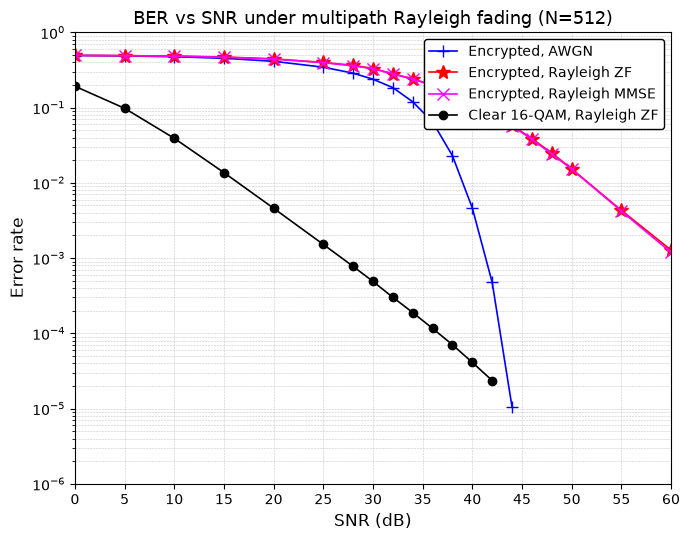

In [4]:
snr_list = [0, 5, 10, 15, 20, 25, 28, 30, 32, 34, 36, 38, 40, 42, 44, 46, 48, 50, 55, 60]
frames_per_rep = 10

def run_once_factory(mode):
    def run_once(snr_db, seed):
        torch.manual_seed(seed)
        b   = binary_source([frames_per_rep, num_ofdm_symbols, fft_size, num_bits_per_symbol])
        lat = (mapper(b).squeeze(-1) * qam_lattice_scale).to(torch.complex128)

        if mode.startswith("clear"):
            Xf, Pxf = lat, 10.0
        else:
            Xf  = encryptor.encrypt(lat)
            Pxf = (Xf.abs() ** 2).mean().item()

        txp = channel_attenuation ** 2 * Pxf
        n0  = txp / (num_bits_per_symbol * 10 ** (snr_db / 10))

        if "awgn" in mode:
            H_eff = channel_attenuation
            Y = channel_attenuation * Xf + awgn128(Xf.shape, n0)
            rx = Y / channel_attenuation
        else:
            H  = rayleigh_freq_response(frames_per_rep, fft_size)
            Y  = channel_attenuation * H * Xf + awgn128(Xf.shape, n0)
            rx = equalize(Y, channel_attenuation * H, n0, Pxf,
                          "mmse" if "mmse" in mode else "zf")

        if mode.startswith("clear"):
            dec = rx
        else:
            dec = encryptor.decrypt_w_babai(rx, use_round=True)

        sym = qam16_lattice_to_normalized(qam16_slicer_lattice(dec))
        rb  = nearest_neighbor_qam_demapper(sym, mapper, num_bits_per_symbol)
        return float(bit_error_rate(b, rb))
    return run_once

results = {}
for label, mode in [("Encrypted, AWGN",          "enc_awgn"),
                    ("Encrypted, Rayleigh ZF",   "enc_ray_zf"),
                    ("Encrypted, Rayleigh MMSE", "enc_ray_mmse"),
                    ("Clear 16-QAM, Rayleigh ZF","clear_ray_zf")]:
    print(f"\n=== {label} ===")
    results[label] = snr_sweep_ber(run_once_factory(mode), snr_list, min_reps=5, max_reps=30)

plot_ber_vs_snr(results, title=f"BER vs SNR under multipath Rayleigh fading (N={fft_size})")

## What to report
1. **Fading penalty of the encrypted scheme.** Over AWGN the encrypted waterfall sits near
   46 dB (N=512). Under Rayleigh the encrypted curves lose the waterfall shape entirely:
   BER decays slowly and needs tens of dB more for the same reliability.
2. **The avalanche mechanism.** ZF equalisation multiplies the noise on subcarrier k by
   1/|H_k|²; Babai decryption then mixes that enhanced noise through R⁻¹ across the whole
   N-dimensional block, so a single deep fade corrupts entire decrypted vectors. Clear
   16-QAM on the identical channel only loses the faded subcarriers — the gap between the
   clear-Rayleigh and encrypted-Rayleigh curves is a direct measurement of this avalanche.
3. **MMSE does not rescue it.** Errors are dominated by worst-subcarrier outages rather
   than average noise, so MMSE ≈ ZF here. Meaningful mitigation must break the outage:
   per-subcarrier power loading, channel coding across blocks, or restricting encryption
   blocks to coherent sub-bands — natural future work.
4. **Limitations.** Perfect CSI, quasi-static block fading, no Doppler, no channel code.
   Swapping in `sionna.phy.channel.tr38901` TDL-A/B/C adds standardised 3GPP delay
   spreads and mobility on top of this framework.